In [94]:
import os

import pandas as pd
from numpy.ma.extras import unique

from utils.vizualization import plot_hist_boxplot
from utils.overview import get_missed_info, get_duplicated_info

In [95]:
HOME = os.getcwd()

In [96]:
rides_options = {
    "filepath_or_buffer": f"{HOME}/data/rides.csv",
    "encoding": "utf-8",
    "parse_dates": ["Start Date", "End Date"],
}

weather_options = {
    "filepath_or_buffer": f"{HOME}/data/weather.csv",
    "encoding": "utf-8",
    "parse_dates": ["Datetime"]
}

try:
    rides_data = pd.read_csv(**rides_options)
    weather_data = pd.read_csv(**weather_options)
except:
    rides_data = pd.read_csv(**rides_options, sep=";")
    weather_data = pd.read_csv(**weather_options, sep=";")

In [97]:
rides_data.sample(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
2970,103159,2023-04-25 14:53:26,2023-04-25 15:46:16,Шевченко,Юго-Восточный,Железнодорожная,Центральный,4103.0,0
44830,143039,2023-06-08 19:08:42,2023-06-08 19:32:00,Луговая,Октябрьский,Маяковского,центральный,4095.0,0
94175,190026,2023-07-24 10:46:10,2023-07-24 11:02:33,Комарова,Ленинский,Железнодорожная,Центральный,2875.0,0
88782,184906,2023-07-19 21:05:39,2023-07-19 21:34:39,Вишневая,Юго-Восточный,Чапаева,Северо-Западный,5072.0,0
35689,134324,2023-05-30 22:06:08,2023-05-30 22:27:41,Красная,Северо-Западный,Карла Маркса,ленинский,3541.0,0
60519,157957,2023-06-23 21:02:25,2023-06-23 21:17:17,калинина,ленинский,спортивная,Октябрьский,2816.0,0
64555,161783,2023-06-27 07:59:16,2023-06-27 08:16:28,Юбилейная,Юго-Восточный,Садовая,Заречный,2233.0,0
10990,110800,2023-05-04 17:13:51,2023-05-04 17:41:39,Маяковского,центральный,ул. школьная,Северо-Западный,3557.0,0
63472,160753,2023-06-25 23:22:05,2023-06-25 23:57:46,ул. пионерская,Заречный,ул.гагарина,центральный,6260.0,0
18897,118335,2023-05-13 14:53:33,2023-05-13 15:31:57,ул. шевченко,юго-восточный,ул.партизанская,ленинский,4086.0,0


In [98]:
rides_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Id              102255 non-null  int64         
 1   Start Date      102255 non-null  datetime64[ns]
 2   End Date        101676 non-null  datetime64[ns]
 3   Start Location  102255 non-null  object        
 4   Start District  102255 non-null  object        
 5   End Location    102255 non-null  object        
 6   End District    102255 non-null  object        
 7   Distance        101022 non-null  float64       
 8   Promo           102255 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(4)
memory usage: 7.0+ MB


In [99]:
rides_data["Promo"] = rides_data["Promo"].astype(object)

In [100]:
rows, cols = rides_data.shape
print(f"Кол-во строк: {rows}\nКол-во столбцов: {cols}")

Кол-во строк: 102255
Кол-во столбцов: 9


In [101]:
get_missed_info(rides_data, rows, cols)


Проверка пропусков
Кол-во пропусков: 1812
Доля пропусков: 0.2%
Доля строк с пропусками: 1.8%


In [102]:
get_duplicated_info(rides_data)


Проверка на дубликаты
Кол-ва дубликатов: 4883


In [103]:
rides_num = rides_data["Distance"]

rides_num.to_frame().describe().T

,count,mean,std,min,25%,50%,75%,max
Distance,101022.0,27291.098424,309718.565282,1.0,3044.0,3702.0,4429.0,7569789.0


In [104]:
rides_cat = rides_data.select_dtypes(include=object)

rides_cat.describe().T

,count,unique,top,freq
Start Location,102255,463,Ломоносова,1675
Start District,102255,13,Центральный,18115
End Location,102255,495,Спортивная,1511
End District,102255,14,Центральный,18878
Promo,102255,2,0,100235


In [105]:
for cat in rides_cat.columns:
    print("=" * 40)
    print(f"Column: {cat}")
    print("- Unique values:", rides_data[cat].nunique(dropna=False))
    print("- Top 30 most frequent values:")
    print(rides_data[cat].value_counts(dropna=False).head(30))
    print()

Column: Start Location
- Unique values: 463
- Top 30 most frequent values:
Start Location
Ломоносова       1675
Луговая          1655
Майская          1648
Восточная        1584
Спортивная       1583
Буденного        1566
Пионерская       1196
Шоссейная        1130
Садовая          1128
Чехова           1119
Октябрьская      1113
Комсомольская    1100
Чапаева           943
Новая             909
Школьная          902
Строительная      884
Березовая         880
Первомайская      880
Рабочая           875
Цветочная         867
Красная           858
Лермонтова        852
Московская        834
Колхозная         834
Некрасова         833
Заводская         828
Комарова          809
Суворова          805
Подгорная         801
Партизанская      799
Name: count, dtype: int64

Column: Start District
- Unique values: 13
- Top 30 most frequent values:
Start District
Центральный        18115
Юго-Восточный      13542
Ленинский          11308
Северо-Западный    11304
Октябрьский         9729
центральн

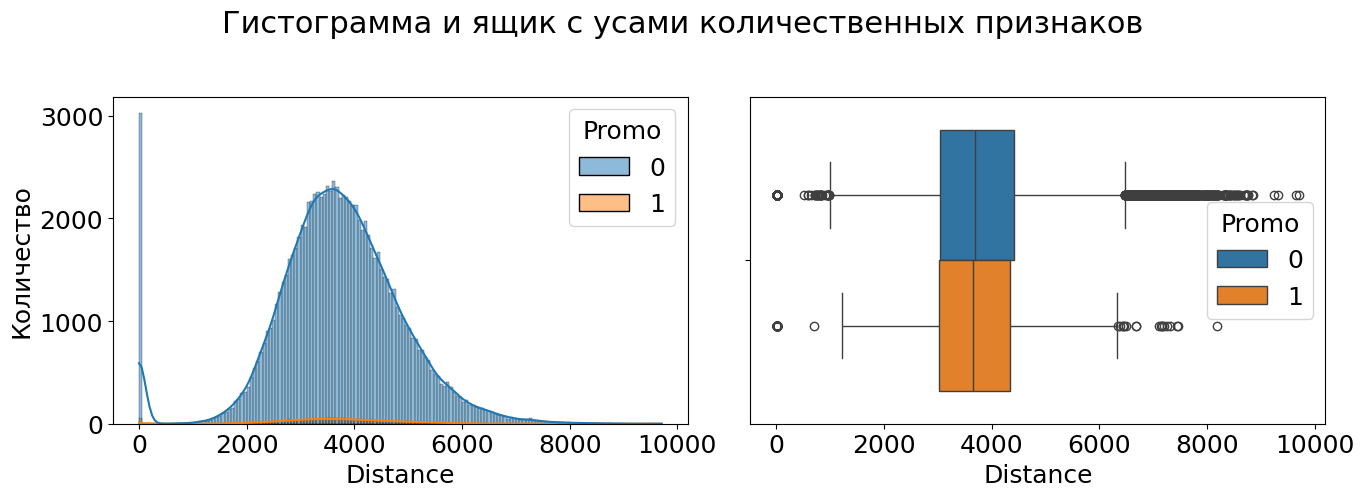

In [106]:
rides_data_clean = rides_data[rides_data['Distance'] < 10000]  # 50 км

plot_hist_boxplot(data=rides_data_clean, cols=["Distance"], hue="Promo", kde=True)

In [107]:
weather_data.sample(10)

,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration
33,2023-04-02 08:00:00,9.010245,0.2,25.919998,9.686609,98,0.6060612
3121,2023-08-09 00:00:00,16.030245,0,11.879999,4.32,97,0
2737,2023-07-24 00:00:00,18.820246,0,10.440001,1.4399999,42,0
1020,2023-05-13 11:00:00,14.860246,0.1,26.28,11.043261,50,29.69697
12,2023-04-01 11:00:00,9.920245,0.4,57.6,22.545315,100,0
3661,2023-08-31 12:00:00,18.970245,0,25.56,10.390226,59,24.242424
1189,2023-05-20 12:00:00,17.800245,0,28.08,13.551501,100,0
1945,2023-06-21 00:00:00,20.230246,0,10.08,0.8049845,32,0
2535,2023-07-15 14:00:00,32.990246,0,39.6,9.885262,30,41.81818
2765,2023-07-25 04:00:00,17.480246,0,18.359999,7.928177,48,2.060606


In [108]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Datetime             3672 non-null   datetime64[ns]
 1   Temperature          3618 non-null   object        
 2   Precipitation Total  3643 non-null   object        
 3   Wind Gust            3673 non-null   object        
 4   Wind Speed           3657 non-null   object        
 5   Cloud Cover Total    3653 non-null   object        
 6   Sunshine Duration    3661 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 201.0+ KB


In [111]:
rows, cols = rides_data.shape
print(f"Кол-во строк: {rows}\nКол-во столбцов: {cols}")

Кол-во строк: 102255
Кол-во столбцов: 9


In [112]:
get_missed_info(weather_data, rows, cols)


Проверка пропусков
Кол-во пропусков: 134
Доля пропусков: 0.0%
Доля строк с пропусками: 0.1%


In [113]:
get_duplicated_info(weather_data)


Проверка на дубликаты
Кол-ва дубликатов: 0
